# Lecture 2: Command Line, Python Environments, and Git Basics

**PHYS690: Computational Methods for Physics Research**  
**Tuesday, September 1, 2026**

Today we move from a notebook-only workflow toward the everyday mechanics of research computing: files, paths, terminals, Python environments, scripts, Git commits, and branches.

## How to use this notebook

This notebook is designed to be run locally in VS Code on your laptop. Open the full course repository folder in VS Code, select your local Python environment as the notebook kernel, and keep a VS Code terminal open next to this notebook. Windows users should choose Git Bash as the VS Code terminal profile so the same Unix-style commands work throughout the course.

Some exercises happen in notebook cells. Other exercises ask you to type commands in the VS Code terminal. The alternation is intentional: research workflows usually involve both.

## Resources for today

- [Unit 1 Resources: Research Computing Foundations](../resources/unit-1-research-computing.md)
- [VS Code setup and troubleshooting](../resources/vscode.md)
- [Software Carpentry lessons](https://swcarpentry.github.io/)
- [Pro Git](https://git-scm.com/book/en/v2)
- [Python 3 documentation](https://docs.python.org/3/)

The Unit 1 resource page is the home base. The other links are references you can return to when a command, Git idea, or Python behavior needs more detail.

## Guiding idea

A computational result is not just a number or a plot. It is a chain of decisions:

- where files live;
- which data were used;
- which Python environment ran the code;
- which script or notebook generated the result;
- which Git commit records the state of the work.

Today is about making those decisions visible.

## Safety for today's Git practice

For now, all practice can happen inside this course repository. We will create a scratch area at `scratch/lecture02/`. You may make local practice commits and branches, but do not push practice branches to GitHub unless instructed.

Next step for later lectures and assignments: you will create your own GitHub repository for your work.

# Part 1: Python environments in VS Code

A Python environment is the specific Python executable plus the packages installed with it. If two people run the same notebook with different environments, they may get different behavior.

For this course, use a Bash-style terminal: macOS Terminal on macOS and Git Bash inside VS Code on Windows.

The commands below create `.venv` and install the common course packages. You only need to do this setup once for this repository, unless you delete `.venv` or need to add new packages.

One-time setup on macOS:

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install numpy scipy matplotlib pandas ipykernel ipython
```

One-time setup on Windows Git Bash:

```bash
python -m venv .venv
source .venv/Scripts/activate
python -m pip install numpy scipy matplotlib pandas ipykernel ipython
```

The activation path is different on Windows because the virtual environment stores executables in `.venv/Scripts/`.

For future work in this same repository, you do **not** need to recreate the environment or reinstall packages every time. Open the VS Code terminal in the repository root and reactivate the existing environment before running notebooks or scripts.

Future activation on macOS:

```bash
source .venv/bin/activate
echo $VIRTUAL_ENV
```

Future activation on Windows Git Bash:

```bash
source .venv/Scripts/activate
echo $VIRTUAL_ENV
```

The `source .../activate` command sets shell environment variables such as `PATH` and `VIRTUAL_ENV`, so `python` and `pip` point to this repository's `.venv`. If `echo $VIRTUAL_ENV` prints a path ending in `.venv`, the environment is active. If it prints a blank line, activate the environment again. Then select the `.venv` kernel for the notebook. See the [VS Code setup resource](../resources/vscode.md) for more detail.

In [1]:
from pathlib import Path
import sys

# Inspect the Python environment that is running this notebook.
current_dir = Path.cwd()
project_root_guess = current_dir.parent if current_dir.name == "lectures" else current_dir

print("Python executable:", sys.executable)
print("Environment prefix:", sys.prefix)
print("Expected project .venv:", project_root_guess / ".venv")

Python executable: /Users/jrsteven/wm/gradcompphys/.venv/bin/python
Environment prefix: /Users/jrsteven/wm/gradcompphys/.venv
Expected project .venv: /Users/jrsteven/wm/gradcompphys/.venv


### Terminal exercise: check Python and IPython

Run these in the VS Code terminal after activating `.venv`:

```bash
python --version
python -m pip list
```

If the notebook and the terminal are using different Python environments, pause and fix that before moving on.

# Part 2: Notebook setup check

Run this cell after the environment setup. It imports the tools used later and checks where this notebook thinks the project root is.

Python reminder: `import` statements load tools that are not built into the smallest core of Python. The `Path` object from `pathlib` represents a file or directory location and gives us convenient methods such as `.cwd()`, `.parent`, `.resolve()`, and `.exists()`.

In [2]:
# Imports load tools from Python modules so we can use them below.
from pathlib import Path
import platform
import subprocess
import sys

# Start from the current working directory. If VS Code starts us inside lectures/, move up one level.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "lectures":
    PROJECT_ROOT = PROJECT_ROOT.parent

# The / operator joins Path objects and folder names into a new path.
SCRATCH_DIR = PROJECT_ROOT / "scratch" / "lecture02"

print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])
print("Operating system:", platform.platform())
print("Notebook working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Scratch directory:", SCRATCH_DIR)

Python executable: /Users/jrsteven/wm/gradcompphys/.venv/bin/python
Python version: 3.14.7
Operating system: macOS-26.6.2-arm64-arm-64bit-Mach-O
Notebook working directory: /Users/jrsteven/wm/gradcompphys/lectures
Project root: /Users/jrsteven/wm/gradcompphys
Scratch directory: /Users/jrsteven/wm/gradcompphys/scratch/lecture02


### Terminal exercise: where am I?

In the VS Code terminal, run:

```bash
pwd
ls
git status --short
```

The goal is not to memorize commands. The goal is to know how to ask: Where am I? What files are here? Is Git tracking any changes?

# Part 3: Files, directories, and paths

A path is an address for a file or directory. Relative paths are interpreted from where you are now. Absolute paths start from the root of the filesystem.

Examples:

- `README.md` is a relative path to the course home page if you are at the repository root.
- `resources/unit-1-research-computing.md` is a relative path to a resource file.
- `../resources/vscode.md` means go up one directory, then enter `resources/`.

Python reminder: the next code cell introduces a **list**, which is an ordered collection written with square brackets: `[first_item, second_item, third_item]`. We use lists whenever we want to store several related values and loop over them.

In [3]:
# A Python list stores multiple values in order.
# Here, each value in the list is a Path object.
example_paths = [
    Path("README.md"),
    Path("resources") / "unit-1-research-computing.md",
    Path("lectures") / "lecture01_8_27_26_workflows.ipynb",
]

# A for loop repeats the same commands once for each item in the list.
for path in example_paths:
    resolved = (PROJECT_ROOT / path).resolve()
    print(f"relative: {path}")
    print(f"absolute: {resolved}")
    print(f"exists:   {resolved.exists()}")
    print()

relative: README.md
absolute: /Users/jrsteven/wm/gradcompphys/README.md
exists:   True

relative: resources/unit-1-research-computing.md
absolute: /Users/jrsteven/wm/gradcompphys/resources/unit-1-research-computing.md
exists:   True

relative: lectures/lecture01_8_27_26_workflows.ipynb
absolute: /Users/jrsteven/wm/gradcompphys/lectures/lecture01_8_27_26_workflows.ipynb
exists:   True



### Notebook exercise

In the code cell below, add one more path from this repository to `example_paths_2`. Run the cell and confirm whether the file exists.

In [4]:
# Add one more Path object from the repository to this list.
example_paths_2 = [
    Path("schedule.md"),
    Path("resources") / "vscode.md",
]

for path in example_paths_2:
    print(f"{path}: {(PROJECT_ROOT / path).exists()}")

schedule.md: True
resources/vscode.md: True


## Common shell operations

| Goal | Bash-style command in macOS Terminal or Windows Git Bash |
| --- | --- |
| Print current directory | `pwd` |
| List files | `ls` |
| Change directory | `cd path/to/folder` |
| Make a directory | `mkdir -p scratch/lecture02` |
| View a short text file | `head file.txt` |
| Print a file | `cat file.txt` |

# Part 4: Create a small project area

The next cell creates a miniature project area inside this repository. This is practice for the structure we will use in assignments and projects.

In [5]:
# This list contains folder names as strings.
# The loop creates one subdirectory for each name.
for subdirectory in ["data", "scripts", "figures"]:
    (SCRATCH_DIR / subdirectory).mkdir(parents=True, exist_ok=True)

for path in sorted(SCRATCH_DIR.iterdir()):
    print(path.relative_to(PROJECT_ROOT))

scratch/lecture02/data
scratch/lecture02/figures
scratch/lecture02/notes
scratch/lecture02/scripts


### Terminal exercise: inspect the scratch area

Run these commands from the repository root:

```bash
ls scratch
ls scratch/lecture02
```

These commands should work in macOS Terminal or Windows Git Bash.

# Part 5: Create and inspect a small data file

A reproducible workflow keeps raw inputs separate from code and figures. Here we create a tiny synthetic data file so we can practice moving between Python, the filesystem, and the terminal.

Physically, imagine a simple system that is displaced from equilibrium and then relaxes back toward zero. The measured quantity could be a detector signal, a normalized position, a voltage, or the envelope of a damped oscillation. Many first-order decay or relaxation processes have the same mathematical shape:

$$x_{\mathrm{true}}(t) = x_0 e^{-t/\tau}$$

where $x_0$ is the initial signal and $\tau$ is the characteristic decay time. Real measurements are not exact, so our synthetic observations include small random measurement errors:

$$x_{\mathrm{meas}}(t_i) = x_{\mathrm{true}}(t_i) + \epsilon_i, \qquad \epsilon_i \sim \mathcal{N}(0, \sigma^2).$$

For today's toy data set, we use $x_0 = 1.0$, $\tau = 3.0\ \mathrm{s}$, and $\sigma = 0.025$. The time column is in seconds. The `position` column is in arbitrary units because the main goal today is workflow practice, not model fitting. The CSV also stores `position_error`, which represents the one-standard-deviation uncertainty $\sigma_i$ for each measured point.

Python reminder: the code below builds three lists: one for times, one for measured positions, and one for position uncertainties. A compact pattern like `[expression for item in collection]` is called a **list comprehension**. It is a short way to build a list by repeating a calculation.

In [6]:
from math import exp
from random import Random

# Choose simple physical parameters for an exponential relaxation model.
x0 = 1.0
tau_s = 3.0
sigma_position = 0.025

# Generate a list of times: 0.0, 0.5, 1.0, ..., 10.0 seconds.
rng = Random(20260901)
time_s = [0.5 * index for index in range(21)]

# Generate one noisy position measurement and one error bar for each time.
position = [x0 * exp(-t / tau_s) + rng.gauss(0.0, sigma_position) for t in time_s]
position_error = [sigma_position for _ in time_s]

# Write the data to a CSV file inside the scratch data directory.
data_path = SCRATCH_DIR / "data" / "decay_measurements.csv"
# The with block opens the file and automatically closes it when the block ends.
with data_path.open("w") as output_file:
    output_file.write("time_s,position,position_error\n")
    # zip pairs the matching time, position, and error values together.
    for t, x, dx in zip(time_s, position, position_error):
        output_file.write(f"{t:.3f},{x:.6f},{dx:.6f}\n")

print("Wrote:", data_path.relative_to(PROJECT_ROOT))

Wrote: scratch/lecture02/data/decay_measurements.csv


### Terminal exercise: look at the file

Run this from the repository root:

```bash
head scratch/lecture02/data/decay_measurements.csv
```

Then answer: What are the column names? Which column will become the vertical error bars? How many data rows do you expect?

_Your answer here._

# Part 6: Read the file back into Python

Now we close the loop: Python created a file, the terminal inspected the file, and Python reads it back from disk. The plotting cell below uses NumPy and Matplotlib; if that import fails, return to Part 1, set up/select your `.venv`, restart the notebook kernel, and rerun from the top.

Python reminder: a **dictionary** stores labeled values as key-value pairs. For example, `row["time_s"]` means "look up the value stored under the key `time_s` in this row." The `csv.DictReader` tool reads each CSV row as a dictionary whose keys come from the column names.

In [7]:
import csv

# DictReader turns each CSV row into a dictionary of text values.
# loaded_rows is therefore a list of dictionaries, one dictionary per row.
with data_path.open() as input_file:
    loaded_rows = list(csv.DictReader(input_file))

# type(...) tells us what kind of Python object we are working with.
print("loaded_rows object type:", type(loaded_rows))
print("one row object type:", type(loaded_rows[0]))

# Look up values by column name, then convert the text into floating-point numbers.
time_loaded = [float(row["time_s"]) for row in loaded_rows]
position_loaded = [float(row["position"]) for row in loaded_rows]
position_error_loaded = [float(row["position_error"]) for row in loaded_rows]

print("columns:", loaded_rows[0].keys())
print("rows:", len(loaded_rows))
print("first row:", loaded_rows[0])

loaded_rows object type: <class 'list'>
one row object type: <class 'dict'>
columns: dict_keys(['time_s', 'position', 'position_error'])
rows: 21
first row: {'time_s': '0.000', 'position': '1.001618', 'position_error': '0.025000'}


Now do some computation with the loaded data

In [8]:
mean_position = sum(position_loaded) / len(position_loaded)
print(f'n = {len(position_loaded)}')
print(f'mean position = {mean_position:.4f}')
print(f'min position = {min(position_loaded):.4f}')
print(f'max position = {max(position_loaded):.4f}')

n = 21
mean position = 0.3004
min position = -0.0041
max position = 1.0016


# Part 7: Plot the data using installed packages

Now that we've activated the Python environment we can use all the packages for plotting, etc.

Python reminder: a NumPy **array** is similar to a list, but it is designed for numerical calculations. If `time_array` is an array, then `np.exp(-time_array / tau_s)` applies the exponential function to every time value at once.

Matplotlib reminder: `fig, ax = plt.subplots()` creates a figure (`fig`) and a set of axes (`ax`). Most plotting commands are methods on `ax`, such as `ax.errorbar(...)`, `ax.plot(...)`, and `ax.set_xlabel(...)`.

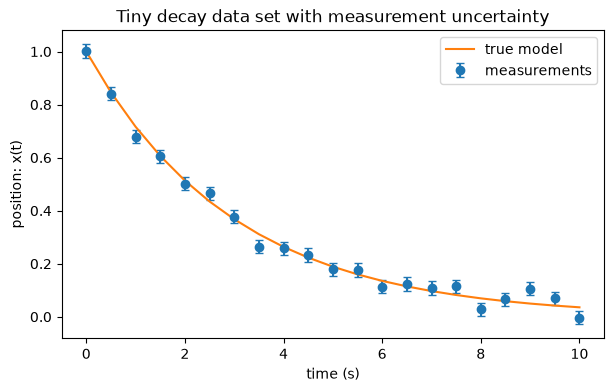

Saved: scratch/lecture02/figures/decay_preview.png


In [9]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# Convert Python lists to NumPy arrays for numerical work.
time_array = np.asarray(time_loaded)
position_array = np.asarray(position_loaded)
position_error_array = np.asarray(position_error_loaded)
true_position_array = x0 * np.exp(-time_array / tau_s)

# Create a figure and axes, then plot data with vertical error bars.
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(time_array, position_array, yerr=position_error_array, fmt="o", capsize=3, label="measurements")
ax.plot(time_array, true_position_array, "-", label="true model")
ax.set_xlabel("time (s)")
ax.set_ylabel("position: x(t)")
ax.set_title("Tiny decay data set with measurement uncertainty")
ax.legend()

preview_plot_path = SCRATCH_DIR / "figures" / "decay_preview.png"
fig.savefig(preview_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", preview_plot_path.relative_to(PROJECT_ROOT))

# Part 8: Jupyter notebooks versus Python scripts

Notebooks are excellent for exploration, explanation, plotting, and guided analysis. Scripts are excellent for repeatable commands, automation, and work that should run without clicking through cells.

Python reminder: a **string** is text surrounded by quotes. In the code below, `script_source` is one long string made by joining a list of shorter strings, where each shorter string becomes one line of a new Python script.

| Tool | Good for | Watch out for |
| --- | --- | --- |
| Notebook (*.ipynb) | narrative, figures, exploration, teaching | hidden state if cells run out of order |
| Script (*.py) | repeatable command-line execution, automation | less room for explanation unless documented well |

Below is a code cell that writes a script file that should be run from the command line that is equivalent to Part 6 of this notebook.


In [10]:
# Write a tiny script that summarizes the CSV file created above.
script_path = SCRATCH_DIR / "scripts" / "summarize_decay.py"

# This is a list of strings; each string will become one line in the script.
script_source = "\n".join(
    [
        "# This script can be run from the command line with a CSV file path.",
        "from pathlib import Path",
        "import csv",
        "import sys",
        "",
        "# def starts a reusable function. This function returns a list of positions.",
        "def read_positions(path):",
        "    with Path(path).open() as input_file:",
        "        # DictReader reads each CSV row as a dictionary keyed by column name.",
        "        rows = list(csv.DictReader(input_file))",
        "    return [float(row['position']) for row in rows]",
        "",
        "# main contains the commands that run when the script is executed.",
        "def main():",
        "    # sys.argv stores the command-line arguments used to run the script.",
        "    if len(sys.argv) != 2:",
        "        raise SystemExit('Usage: python summarize_decay.py path/to/data.csv')",
        "    positions = read_positions(sys.argv[1])",
        "    mean_position = sum(positions) / len(positions)",
        "    print(f'n = {len(positions)}')",
        "    print(f'mean position = {mean_position:.4f}')",
        "    print(f'min position = {min(positions):.4f}')",
        "    print(f'max position = {max(positions):.4f}')",
        "",
        "if __name__ == '__main__':",
        "    main()",
    ]
)

script_path.write_text(script_source + "\n")
print("Wrote:", script_path.relative_to(PROJECT_ROOT))

Wrote: scratch/lecture02/scripts/summarize_decay.py


Open the script using the VSCode file explorer to compare the calculation with what was computed in [Part 6](#part-6-read-the-file-back-into-python)

In [11]:
# subprocess.run executes a terminal command from inside Python.
# The command is written as a list: program name first, then command-line arguments.
_ = subprocess.run([sys.executable, str(script_path), str(data_path)], cwd=PROJECT_ROOT, check=False)

n = 21
mean position = 0.3004
min position = -0.0041
max position = 1.0016


### Terminal exercise: run the script yourself

From the repository root, run:

```bash
python scratch/lecture02/scripts/summarize_decay.py scratch/lecture02/data/decay_measurements.csv
```

If that does not work, check three things: Are you in the repository root? Is `.venv` activated? Does the file path exist?

### Extension exercise:

Add some code to the script to estimate the exponential decay coefficient from neighboring data points and execute the script from the command line. This is **not** a fit; it is a point-to-point calculation.  Use the model

$$x(t) = A e^{-\lambda t},$$

where $\lambda$ is the exponential decay coefficient. Taking the natural logarithm gives

$$y_i = \ln x_i = \ln A - \lambda t_i.$$

Between two neighboring measurements, the slope of $y = \ln x$ versus $t$ is

$$m_i = \frac{\ln x_{i+1} - \ln x_i}{t_{i+1} - t_i}.$$

Since the exponential model predicts a slope of $-\lambda$, the point-to-point estimate of the decay coefficient is

$$\lambda_i = -m_i = \frac{\ln x_i - \ln x_{i+1}}{t_{i+1} - t_i} = \frac{\ln(x_i/x_{i+1})}{t_{i+1} - t_i}.$$

Only compute this for neighboring pairs where both measured positions are positive, since $\ln x$ is not defined for zero or negative values. Ignore `position_error` for this extension exercise.

If there are $M$ valid neighboring pairs, compute the mean point-to-point coefficient:

$$\lambda_{\mathrm{mean}} = \frac{1}{M}\sum_{i=1}^{M}\lambda_i.$$

Your script should print `lambda_mean` as the final result.

# Part 9: Git basics

Git tracks snapshots of a project. The basic cycle is:

1. edit files;
2. inspect changes with `git status` and `git diff`;
3. stage selected files with `git add`;
4. save a snapshot with `git commit`;
5. use branches to try work without mixing it into `main` immediately.

The key idea is control. You decide what belongs in each commit.

### Terminal exercise: make a practice branch and commit

Run these from the repository root. If `git switch` is unavailable, use `git checkout -b lecture02-practice` instead.

```bash
git status
git switch -c lecture02-practice
git add scratch/lecture02/data/decay_measurements.csv scratch/lecture02/scripts/summarize_decay.py scratch/lecture02/figures/decay_preview.png
git commit -m "Practice files, paths, scripts, and Git"
git log --oneline --max-count=5
git branch
```

This is a local practice commit. Do not push it unless instructed.

If Git says it does not know your name or email, see the [Troubleshooting Git section of the VS Code resource](../resources/vscode.md#troubleshooting-git). If the branch already exists, use `git switch lecture02-practice` instead of creating it again.

### Common Git operations

| Goal | Command | What it does |
| --- | --- | --- |
| Check repository state | `git status` | Shows which files are modified, staged, untracked, or clean. |
| See a compact repository state | `git status --short` | Shows the same information in a shorter format. |
| See exact text changes | `git diff` | Shows unstaged changes line by line. |
| Stage one file | `git add path/to/file` | Marks one file to be included in the next commit. |
| Stage several files | `git add file1 file2` | Marks multiple selected files for the next commit. |
| Stage all current changes | `git add .` | Stages all changes under the current directory. Use this carefully. |
| Commit staged changes | `git commit -m "Short message"` | Saves a snapshot of the staged changes with a message. |
| View recent commits | `git log --oneline --max-count=5` | Shows the five most recent commits in compact form. |
| List branches | `git branch` | Shows local branches and marks the current branch with `*`. |
| Create and switch to a branch | `git switch -c branch-name` | Starts a new branch for experimental work. |
| Switch to an existing branch | `git switch branch-name` | Moves your working directory to another branch. |
| Merge another branch into the current branch | `git merge branch-name` | Brings committed changes from another branch into the branch you are currently on. |
| Check GitHub connection | `git remote -v` | Shows the remote repository URLs, if any are configured. |
| Upload committed work | `git push` | Sends local commits to GitHub when a remote is configured. |
| Download remote updates | `git pull` | Brings changes from GitHub into your local repository. |

# Part 10: What should be committed?

Good things to commit:

- source code and notebooks needed to reproduce the work;
- small input data files when allowed;
- generated figures when they are part of the submitted result;
- README files and notes that explain the workflow;
- `requirements.txt` or another environment record.

Things usually not to commit:

- `.venv/`;
- `.ipynb_checkpoints/`;
- large generated files unless required;
- private keys, passwords, tokens, or credentials.

## Next step

For the next phase of the course, we will move from practicing inside the course repository to creating your own GitHub repositories for lectures, assignments, and projects. The habits from today are the foundation: clear paths, local environments, runnable notebooks and scripts, and small Git commits.

Assignments will use private repositories in the course GitHub organization:

https://github.com/WM-PHYS690-Fall2026

Please email me your GitHub username so I can invite you to the organization. After you accept the invitation, visit the [Assignments README](../assignments/README.md) for instructions on creating your own private assignment repository from the assignment template.